In [1]:
import os
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import sys

sys.path.insert(0, "../..")

In [2]:
import chex
import dill
import jax
import jax.numpy as jnp
import json
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import scipy
import torch
import treescope

from flax import nnx
from torch.utils.data import DataLoader
from typing import Any, NamedTuple
from typing_extensions import Protocol, runtime_checkable

from src.dataset import get_iter
from src.datasets.repetition import Repetition
from src.decoding import make_autoregressive
from src.rollout import rollout
from src.utils import parse_dict
from src.verifier import make_compute_returns

# Penzai
from penzai import pz

import IPython

pz.ts.register_as_default()

# Optional automatic array visualization extras:
pz.ts.register_autovisualize_magic()
pz.enable_interactive_context()
pz.ts.active_autovisualizer.set_interactive(pz.ts.ArrayAutovisualizer())


In [3]:
base_path = "/home/bryanpu1/projects/parallel_vs_serial/scaling_jax/results"

# explore only
algo_name = "debug"
# run_name = "reinforce-explore_only-in_traj-scratch_1M-0_cot_tokens-8x8-02-12-26_13_06_55-675fea0d-1fdf-4143-8bbe-2d210bc4bf39"
# run_name = "reinforce-explore_only-large_act_space-in_traj-scratch_1M-0_cot_tokens-8x8-02-12-26_13_31_37-bf844d3a-2297-40b6-8542-f15f1ed60f89"
# run_name = "reinforce-explore_only-large_act_space-quiet_softmax-in_traj-scratch_1M-0_cot_tokens-8x8-02-12-26_13_37_14-7b215eaa-6ee9-46b5-a785-50c7640a0571"
# run_name = "reinforce-explore_only-large_act_space-smaller_model-in_traj-scratch_1M-0_cot_tokens-8x8-02-12-26_16_14_09-859a629e-a8bb-4c4c-8917-216e4cdd492f"
# run_name = "reinforce-explore_only-large_k-smaller_model-in_traj-scratch_1M-0_cot_tokens-8x8-02-13-26_04_16_49-ee0166c8-9320-4000-92e8-b3899dff4f26"

# Large A
# MSE
# run_name = "reward_learner-explore_only-large_act_space-smaller_model-in_traj-scratch_1M-0_cot_tokens-8x8-02-13-26_10_00_25-64063a62-5fc8-4ac9-8b0b-be88b41ea074"

# BCE
# run_name = "reward_learner-explore_only-bce-large_act_space-smaller_model-in_traj-scratch_1M-0_cot_tokens-8x8-02-14-26_07_05_11-9093aac3-3928-4418-9e95-c544b8f903cc"
# run_name = "reward_learner-explore_only-bce-sigmoid_inf-large_act_space-smaller_model-in_traj-scratch_1M-0_cot_tokens-8x8-02-16-26_03_04_56-6060f553-d77d-4414-b3a8-60ad63257dc1"

# Large K
# MSE
# run_name = 'reward_learner-explore_only-large_k-smaller_model-in_traj-scratch_1M-0_cot_tokens-8x8-02-13-26_09_05_13-f58e3da5-73d0-49af-a9d5-94839665d978'
# run_name = "reward_learner-explore_only-large_k-num_blocks_4-in_traj-scratch_1M-0_cot_tokens-8x8-02-16-26_08_50_48-2238c0df-f0e8-4055-af1d-1a0e499fa6e8"

# BCE
# run_name = "reward_learner-explore_only-bce-large_k-smaller_model-in_traj-scratch_1M-0_cot_tokens-8x8-02-14-26_07_07_30-a5e3ad3a-ca69-40d4-b4c7-77ed1ceade46"

# A = 50
run_name = "reward_learner-explore_only-mse-act_50-smaller_model-in_traj-scratch_1M-0_cot_tokens-8x8-02-16-26_02_55_56-2a25e240-2ea3-4441-8a36-de6242a8a71f"

# exploit then commit
# algo_name = "debug-s_3-k_3"
# run_name = "reward_learner-sigmoid-bce-in_traj-scratch_1M-02-16-26_03_08_26-dc10b416-c241-4a78-b7b6-b54a315a2933"
# run_name = "reward_learner-mse-in_traj-scratch_1M-02-14-26_07_08_55-b5ebd498-61a2-425e-9c96-ef93481b48f2"
# run_name = "reward_learner-bce-in_traj-scratch_1M-02-14-26_07_08_27-3e30b0cf-a3a7-4ed0-ad12-5a171262f65e"

# algo_name = "debug_ntp"
# run_name = "ntp-quiet_softmax-scratch_1M-02-11-26_09_22_07-6b95fd18-3c76-44e4-9638-050d38f9e23d"

learner_path = os.path.join(base_path, algo_name, run_name)

In [4]:
eval_seed = 42
num_evals = 1
checkpoint_i = -1

In [5]:
config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))
half_precision = config_dict["half_precision"]
dtype = jnp.bfloat16 if half_precision else jnp.float32

# Get dataset
config = parse_dict(config_dict)
dataset_kwargs = config.dataset_kwargs
batch_size = dataset_kwargs.vocab_size

In [6]:
num_checkpoints = len(os.listdir(os.path.join(learner_path, "models")))

dataset = Repetition(
    dataset_kwargs.context_len,
    dataset_kwargs.vocab_size,
    dataset_kwargs.k,
    True,
    eval_seed,
    "question_only",
    1.0,
    getattr(dataset_kwargs, "num_repeats", None),
    False,
    True,
    0,
)

EOS TOKEN: 51
TOKEN MAP: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33, 34: 34, 35: 35, 36: 36, 37: 37, 38: 38, 39: 39, 40: 40, 41: 41, 42: 42, 43: 43, 44: 44, 45: 45, 46: 46, 47: 47, 48: 48, 49: 49, 50: 50, 51: 51}


In [7]:
out_dim = int(dataset.output_space.n)
data_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    num_workers=0,
)
data_iter = get_iter(data_loader, None, dtype)

In [8]:
last_step = sorted(os.listdir(os.path.join(learner_path, "models")))[checkpoint_i]
train_state = dill.load(
    open(os.path.join(learner_path, "models", last_step), "rb")
)

model = nnx.merge(
    train_state.graphdef,
    train_state.params,
    train_state.rest,
)
model.set_attributes(deterministic=False, decode=False)

In [9]:
batch = next(data_iter)
batch = {
    k: np.repeat(v, num_evals, axis=0)
    for k, v in batch.items()
}

In [10]:
batch

{'sequence': array([[13, 50, 51, ..., 51, 51, 51],
        [39, 50, 51, ..., 51, 51, 51],
        [30, 50, 51, ..., 51, 51, 51],
        ...,
        [14, 50, 51, ..., 51, 51, 51],
        [28, 50, 51, ..., 51, 51, 51],
        [38, 50, 51, ..., 51, 51, 51]], shape=(50, 102)),
 'target': array([[50, 51, 51, ..., 51, 51, 51],
        [50, 51, 51, ..., 51, 51, 51],
        [50, 51, 51, ..., 51, 51, 51],
        ...,
        [50, 51, 51, ..., 51, 51, 51],
        [50, 51, 51, ..., 51, 51, 51],
        [50, 51, 51, ..., 51, 51, 51]], shape=(50, 102)),
 'mask': array([[False,  True,  True, ...,  True,  True,  True],
        [False,  True,  True, ...,  True,  True,  True],
        [False,  True,  True, ...,  True,  True,  True],
        ...,
        [False,  True,  True, ...,  True,  True,  True],
        [False,  True,  True, ...,  True,  True,  True],
        [False,  True,  True, ...,  True,  True,  True]], shape=(50, 102)),
 'pointer_correct': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1]),
 'question_len': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1]),
 'solution_len': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1])}

In [11]:
model = nnx.merge(
    train_state.graphdef,
    train_state.params,
    train_state.rest,
)

if not hasattr(model, "transfer"):
    from src.constants import Identity
    model.transfer = Identity

rng = jax.random.PRNGKey(eval_seed)
rng, rollout_rng = jax.random.split(rng)

# Sample next batch and evaluate
_, init_cache = make_autoregressive(
    model,
    max_decode_len=dataset_kwargs.context_len,
    batch_size=batch_size,
    embed_dim=config_dict["model_config"]["model_kwargs"]["embed_dim"],
    dtype=dtype,
    eval_mode=True,
)
cache = init_cache()
graphdef, _, rest = nnx.split(model, nnx.Cache, ...)

rollout_res = rollout(
    graphdef,
    cache,
    rest,
    rollout_rng,
    batch,
    eos_token=dataset.eos_token_id,
    attempt_length=config.attempt_length,
    deterministic=int(num_evals == 1),
    correct_aware_shift=dataset.correctness_aware_tokens_offset,
    max_token_id_to_shift=dataset.max_token_id_to_shift,
)

/home/bryanpu1/.conda/envs/parallel_vs_serial/lib/python3.10/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=bool with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


In [12]:
model = nnx.merge(
    train_state.graphdef,
    train_state.params,
    train_state.rest,
)
if not hasattr(model, "transfer"):
    from src.constants import Identity
    model.transfer = Identity
model.set_attributes(deterministic=False, decode=False)

res = model.act({
    "sequence": rollout_res.observations
})

In [13]:
intermediates = nnx.pop(model, nnx.Intermediate)

In [14]:
rollout_res.success

Array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True], dtype=bool)

In [15]:
(batch["question_len"] + rollout_res.response_length).astype(int).shape

(50,)

In [16]:
res.shape, rollout_res.observations.shape

((50, 101, 50), (50, 101))

In [17]:
reset_idxes = np.where(rollout_res.observations[0] == dataset.reset_token_id)[0]
if rollout_res.success[0].item():
    reset_idxes = np.concatenate((reset_idxes, [np.argmax(rollout_res.observations[0] == dataset.eos_token_id)]))
reset_idxes[1:] - reset_idxes[:-1]

array([  2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,
         2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,
         2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,
         2,   2,   2,   2,   2,   2,   2,   2,   2,   2, -99])

In [18]:
3 ** 2 * 3

27

In [19]:
for curr_obss in rollout_res.observations[:, 2::2]: 
    print(np.unique(curr_obss, return_counts=True))

(array([ 0,  1,  5,  6,  7,  8, 19, 34, 35, 36, 43, 46, 47], dtype=int32), array([ 2,  1,  1,  1,  1,  7,  1, 29,  1,  2,  2,  1,  1]))
(array([ 0,  1,  3,  6,  7, 10, 12, 13, 18, 19, 34, 35, 36, 43, 46, 47],
      dtype=int32), array([ 1,  1,  1,  5,  1,  1,  1,  1,  1,  1, 31,  1,  1,  1,  1,  1]))
(array([ 0,  1,  3,  6,  7, 10, 12, 18, 19, 21, 32, 34, 36, 43, 46, 47],
      dtype=int32), array([ 2,  1,  2,  9,  1,  1,  7,  1,  1,  1,  1, 18,  1,  1,  1,  2]))
(array([ 0,  1,  6,  7, 12, 18, 34, 36, 38, 46, 47], dtype=int32), array([ 1,  1, 18,  1,  1,  1, 22,  2,  1,  1,  1]))
(array([ 0,  1,  4,  6,  7, 18, 19, 34, 36, 43, 46, 47], dtype=int32), array([ 1,  1,  1,  8,  1,  1,  1, 32,  1,  1,  1,  1]))
(array([ 0,  1,  3,  5,  6,  7, 10, 11, 13, 14, 18, 19, 34, 35, 36, 37, 47],
      dtype=int32), array([ 1,  1,  8,  1,  1,  1,  1,  3,  1,  5,  2,  1, 16,  1,  2,  1,  4]))
(array([ 0,  1,  6,  7, 12, 14, 18, 19, 34, 36, 46, 47], dtype=int32), array([ 1,  1,  4,  1,  1,  9,  1,  1, 

In [20]:
attn_weights = []
for layer_i in intermediates["gpt"]["gpt"]["layers"]:
    attn_weights.append(np.mean(
        intermediates["gpt"]["gpt"]["layers"][layer_i]["attention"]["attention_weights"].value[0],
        axis=1,
    ))

attn_weights = pz.nx.wrap(
    attn_weights
).tag("layer", "sample", "q", "k")
pz.ts.render_array(
    attn_weights,
    rows=["q"],
    columns=["k"],
    # sliders=["sample"],
)

<Arrayviz rendering>

In [21]:
attn_weights = []
for layer_i in intermediates["gpt"]["gpt"]["layers"]:
    attn_weights.append(
        intermediates["gpt"]["gpt"]["layers"][layer_i]["attention"]["attention_weights"].value[0]
    )

attn_weights = pz.nx.wrap(
    attn_weights
).tag("layer", "sample", "head", "q", "k")
pz.ts.render_array(
    attn_weights,
    rows=["q"],
    columns=["k"],
    sliders=["sample"],
)

<Arrayviz rendering>

In [22]:
train_state.params["embedders"]["token_emb"]["embedding"].value @ train_state.params["embedders"]["token_emb"]["embedding"].value.T

Array([[ 2.2733166 , -0.26571822, -0.10661351, ..., -0.27463594,
        -0.01362741, -0.0130392 ],
       [-0.26571822,  0.6919354 ,  0.10180067, ...,  0.1002576 ,
        -0.11320792, -0.1233891 ],
       [-0.10661351,  0.10180067,  0.2198058 , ...,  0.11890385,
         0.01114506, -0.07603381],
       ...,
       [-0.27463594,  0.1002576 ,  0.11890385, ...,  0.35082173,
        -0.10671407,  0.03693803],
       [-0.01362741, -0.11320792,  0.01114506, ..., -0.10671407,
         0.99389553,  0.13524652],
       [-0.0130392 , -0.1233891 , -0.07603381, ...,  0.03693803,
         0.13524652,  1.2717589 ]], dtype=float32)

In [23]:
rollout_res.observations

Array([[13, 50, 47, ..., 34, 50,  0],
       [39, 50, 47, ..., 34, 50, 34],
       [30, 50, 47, ...,  6, 50, 43],
       ...,
       [14, 50, 47, ..., 34, 50, 14],
       [28, 50, 47, ..., 47, 50,  7],
       [38, 50, 47, ..., 34, 50, 34]], dtype=int32)

In [29]:
res[1]

Array([[ 1.1958599 , -0.09223203,  0.07870417, ...,  0.12281501,
         0.35506538,  0.771503  ],
       [ 1.0830499 ,  1.0327392 ,  0.8023659 , ...,  1.1529142 ,
         0.8809503 ,  0.9629764 ],
       [ 1.0250261 ,  1.0388101 ,  0.7944858 , ...,  1.1354256 ,
         0.8949549 ,  0.95915693],
       ...,
       [ 1.3080101 ,  0.66487074,  0.33371297, ...,  0.6726985 ,
         0.21458404,  0.20455372],
       [ 0.84100395,  0.2763596 ,  0.5707359 , ...,  0.6722052 ,
         0.46815285,  0.55090135],
       [ 1.3079963 ,  0.6656219 ,  0.33377337, ...,  0.67283285,
         0.21484527,  0.20485015]], dtype=float32)

In [24]:
idx = 1
jnp.concatenate((
    rollout_res.observations[idx][:, None],
    res.at[rollout_res.pred_mask == False].set(np.inf)[idx],
), axis=1).T

Array([[39.        , 50.        , 47.        , ..., 34.        ,
        50.        , 34.        ],
       [        inf,  1.0830499 ,         inf, ...,         inf,
         0.84100395,         inf],
       [        inf,  1.0327392 ,         inf, ...,         inf,
         0.2763596 ,         inf],
       ...,
       [        inf,  1.1529142 ,         inf, ...,         inf,
         0.6722052 ,         inf],
       [        inf,  0.8809503 ,         inf, ...,         inf,
         0.46815285,         inf],
       [        inf,  0.9629764 ,         inf, ...,         inf,
         0.55090135,         inf]], dtype=float32)

In [25]:
pz.ts.render_array(
    res.at[rollout_res.pred_mask == False].set(np.inf)
)

<Arrayviz rendering>

In [26]:
scipy.stats.entropy(jax.nn.softmax(res, axis=-1)[:, 1::2], axis=-1)

array([[3.8947358, 3.8938215, 3.891921 , ..., 3.8928022, 3.8928266,
        3.892821 ],
       [3.8948827, 3.894695 , 3.891694 , ..., 3.8811433, 3.8827295,
        3.8829656],
       [3.8950639, 3.8941238, 3.8932467, ..., 3.8809946, 3.8810842,
        3.881167 ],
       ...,
       [3.894257 , 3.8928444, 3.8884842, ..., 3.8814964, 3.8821752,
        3.8827517],
       [3.8939543, 3.8928645, 3.892539 , ..., 3.8794734, 3.879665 ,
        3.8798044],
       [3.894775 , 3.8933604, 3.8900986, ..., 3.8808024, 3.8815098,
        3.882173 ]], shape=(50, 50), dtype=float32)

Text(0.02, 0.5, 'Initial state')

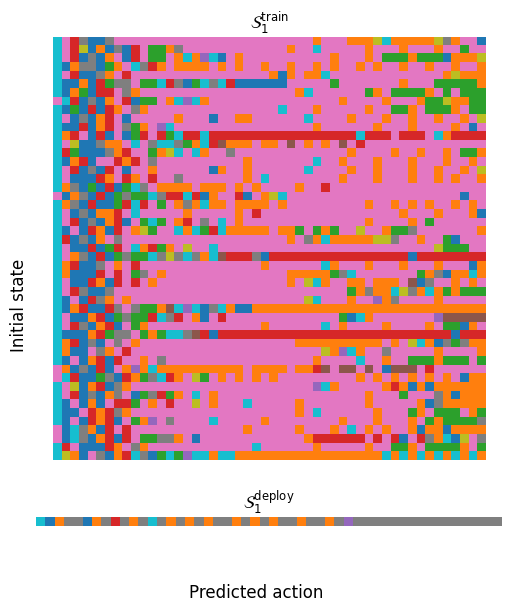

In [27]:
num_cols = 1
num_rows = 2
fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0, 6.0), height_ratios=[4, 1])

axes[0].imshow(rollout_res.observations[:-1, ::2][:, 1:], cmap="tab10")
axes[0].set_title("$\mathcal{S}_1^\\text{train}$")
axes[0].axis("off")
axes[0].autoscale(False)

axes[1].imshow(rollout_res.observations[-1:, ::2][:, 1:], cmap="tab10")
axes[1].set_title("$\mathcal{S}_1^\\text{deploy}$")
axes[1].axis("off")
axes[1].autoscale(False)

fig.supxlabel("Predicted action")
fig.supylabel("Initial state")

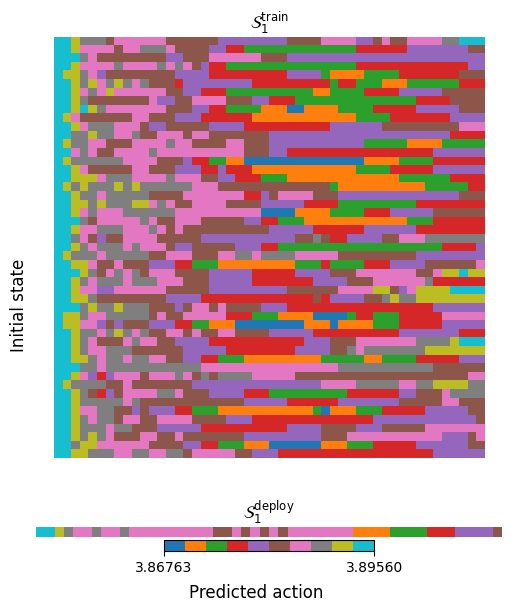

In [28]:
entropies = scipy.stats.entropy(jax.nn.softmax(res, axis=-1)[:, 1::2], axis=-1)
_min, _max = np.amin(entropies), np.amax(entropies)

num_cols = 1
num_rows = 2
fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0, 6.0), height_ratios=[6, 1])

axes[0].imshow(entropies[:-1], cmap="tab10", vmin = _min, vmax = _max)
axes[0].set_title("$\mathcal{S}_1^\\text{train}$")
axes[0].axis("off")
axes[0].autoscale(False)

t = axes[1].imshow(entropies[-1:], cmap="tab10", vmin = _min, vmax = _max)
axes[1].set_title("$\mathcal{S}_1^\\text{deploy}$")
axes[1].axis("off")
axes[1].autoscale(False)

fig.supxlabel("Predicted action")
fig.supylabel("Initial state")
cbar = fig.colorbar(t, orientation='horizontal')
cbar.set_ticks([_min, _max])